## Basic Setup

In [1]:
import os
import random
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from keras.layers import BatchNormalization
from keras.optimizers import SGD
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

os.chdir('../../../../') # move four level up to the base pathfrom src.utils import load_and_preprocess_images
from src.utils import load_and_preprocess_images, plot_history
from src.model_evaluation import evaluate_model
from src.plot_images import plot_images, plot_predictions, plot_false_positives, plot_false_negatives

In [2]:
# set the random seeds to make sure that the results are reproducible
SEED = 1234
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)

In [3]:
model_name = '1_synthetic_eyes'
transfer_learning_stage = '1_full_network'
repo_path = '/Users/hendriksippel/Documents/Repositories/cbs-mldl-drowsiness-detection'

syntheticDataPath = repo_path + '/data/Unity_Data_Test_Train'
syntheticTrainingPath = syntheticDataPath + '/TrainingSet'
syntheticTestPath = syntheticDataPath + '/TestSet'

In [4]:
comment = "evening run"
model_file_path = repo_path + f"/models/cnn/{model_name}/{transfer_learning_stage}/weights/{comment}_model.keras"
ckpt_file_path = repo_path + f"/models/cnn/{model_name}/{transfer_learning_stage}/ckpt/{comment}_checkpoint.model.keras"
history_file_path = repo_path + f"/models/cnn/{model_name}/{transfer_learning_stage}/history/{comment}_history.csv"
assert not os.path.exists(ckpt_file_path), "Model already exists. Please change the comment."

In [5]:
# Hyperparameters
BATCH_SIZE = 64
IMAGE_SIZE = (224, 224)
INPUT_SHAPE = IMAGE_SIZE + (3,)

DATA_AUG_RATE = 0.1
LOSS_FUNCTION = 'sparse_categorical_crossentropy'

FT_EPOCHS = 100
FT_LEARNING_RATE = 0.00001
OPTIMIZER = SGD(learning_rate=FT_LEARNING_RATE)

In [6]:
early_stop = EarlyStopping(monitor="val_accuracy", mode="max", patience=30, start_from_epoch=10)
checkpoint = ModelCheckpoint(ckpt_file_path, monitor="val_accuracy", mode="max", save_best_only=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=15, min_lr=0.00001, verbose=1)

In [7]:
labels = ['Closed', 'Open']
synth_train_data = load_and_preprocess_images(syntheticTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, data_aug_rate=DATA_AUG_RATE, subset='training', validation_split=0.2)
synth_valid_data = load_and_preprocess_images(syntheticTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, subset='validation', validation_split=0.2)
synth_test_data = load_and_preprocess_images(syntheticTestPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, shuffle=False)

Found 4743 files belonging to 2 classes.
Using 3795 files for training.
Found 4743 files belonging to 2 classes.
Using 948 files for validation.
Found 1187 files belonging to 2 classes.


## Finetuning the Pre-Trained Model

In [ ]:
# define the path to the pretrained model
pretrained_model_path = repo_path + '/models/cnn/1_synthetic_eyes/0_last_layers/weights/afternoon run_model.keras'

In [8]:
# load the model with compiling
model = tf.keras.models.load_model(pretrained_model_path, compile=True)

# get benchmark results by evaluating the model on the test set
evaluate_model(model, synth_test_data, show_cm=False, show_roc=False)

19/19 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.9507 - loss: 6.8038
Test loss: 6.88775634765625
Test accuracy: 0.92586350440979


In [9]:
# load and override the model again without compiling it
model = tf.keras.models.load_model(pretrained_model_path, compile=False)

# unfreeze all layers which are not BN layers
for layer in model.layers:
    if isinstance(layer, BatchNormalization): # freeze BN layers
        layer.trainable = False
    else: # unfreeze all other layers
        layer.trainable = True

# display the summary if needed
model.summary(show_trainable=True)

In [10]:
# compile the model with the same optimizer and loss function
model.compile(loss=LOSS_FUNCTION, optimizer=OPTIMIZER, metrics=['accuracy'])

# train the entire model with the same data but lower learning rate
history = model.fit(
    synth_train_data,
    validation_data=synth_valid_data,
    epochs=FT_EPOCHS,
    callbacks=[checkpoint] # early_stop, reduce_lr
    )

Epoch 1/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9363 - loss: 6.8400
Epoch 1: val_accuracy improved from -inf to 0.93460, saving model to /Users/hendriksippel/Documents/Repositories/cbs-mldl-drowsiness-detection/models/cnn/1_synthetic_eyes/1_full_network/ckpt/evening run_checkpoint.model.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 319s 5s/step - accuracy: 0.9363 - loss: 6.8399 - val_accuracy: 0.9346 - val_loss: 6.8589 - learning_rate: 1.0000e-05
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9376 - loss: 6.8131
Epoch 2: val_accuracy did not improve from 0.93460
60/60 ━━━━━━━━━━━━━━━━━━━━ 251s 4s/step - accuracy: 0.9376 - loss: 6.8134 - val_accuracy: 0.9346 - val_loss: 6.8656 - learning_rate: 1.0000e-05
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9463 - loss: 6.8177
Epoch 3: val_accuracy did not improve from 0.93460
60/60 ━━━━━━━━━━━━━━━━━━━━ 240s 4s/step - accuracy: 0.9463 - loss: 6.8179 - val_accuracy: 0.9325 - val_loss: 6.8610 - learning_rate:

In [11]:
# save the history
history_df = pd.DataFrame(history.history)
history_df['epoch'] = history.epoch
history_df.to_csv(history_file_path, index=False)

In [12]:
# load the best model
model.load_weights(ckpt_file_path)

In [13]:
# save the model
model.save(model_file_path)

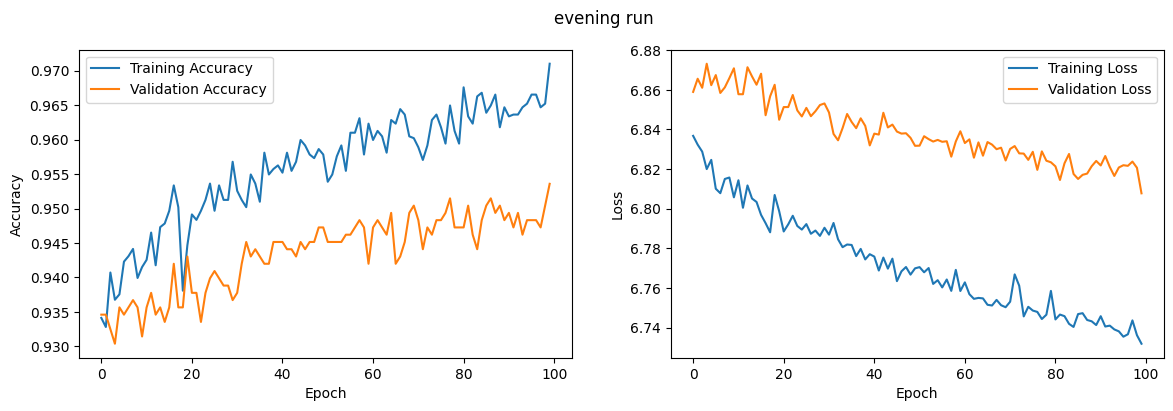

Best train_accuracy: 0.971
Best train_loss: 6.7318
Best val_accuracy: 0.9536
Best val_loss: 6.8078
Last improvement at epoch: 100


In [14]:
plot_history(comment=comment, history=history)

In [15]:
evaluate_model(model, synth_test_data)

19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 561ms/step - accuracy: 0.9560 - loss: 6.7739
Test loss: 6.833213806152344
Test accuracy: 0.9435551762580872
